In [1]:
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
.appName('CDFRS POC') \
.master('yarn') \
.getOrCreate()

higgs_path = "hdfs:///data/HIGGS.csv"

num_features = 28
cols = ["label"] + [f"x{i}" for i in range(1, num_features+1)]

higgs_df = spark.read.csv(
    higgs_path,
    header = False,
    inferSchema = True
).toDF(*cols)

26/02/27 21:16:05 WARN Utils: Your hostname, praneet-HP-ProBook-440-G1 resolves to a loopback address: 127.0.1.1; using 192.168.1.38 instead (on interface wlo1)
26/02/27 21:16:05 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/27 21:16:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/27 21:16:10 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.
                                                                                

In [2]:
epsilon = 0.05
alpha = 0.10
M = 512

import math
K = int(((math.log(2/alpha))/(2*epsilon**2)))

s = max(1, M // max(1, K))

In [3]:
higgs_blocks = higgs_df.repartition(M)

In [4]:
from pyspark.sql.types import IntegerType
import pyspark.sql.functions as F

higgs_with_subset = higgs_blocks.withColumn("subset_id", (F.rand(seed=42)*s).cast(IntegerType()))

In [5]:
import random

chosen_subset_id = random.randint(0, s-1)

D = higgs_with_subset.filter(F.col("subset_id") == chosen_subset_id)
D = D.drop("subset_id")

In [6]:
from pyspark.sql.window import Window

k_cdf = 50

D_shuffled = D.orderBy(F.rand(seed=123))

window_spec = Window.orderBy(F.monotonically_increasing_id())

D_indexed = D_shuffled.withColumn(
    "row_idx",
    F.row_number().over(window_spec) - 1
)

D_with_block = D_indexed.withColumn("cdfrs_block_id", (F.col("row_idx") % k_cdf).cast(IntegerType()))

In [7]:
cdfrs_output_path = "hdfs:///data/higgs_cdfrs_blocks"

D_with_block.write.partitionBy("cdfrs_block_id").mode("overwrite").parquet(cdfrs_output_path)

26/01/02 09:49:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/02 09:49:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/02 09:49:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/02 09:49:27 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/01/02 09:51:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/02 09:51:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance

In [2]:
cdfrs_blocks_df = spark.read.parquet("hdfs:///data/higgs_cdfrs_blocks")
cdfrs_blocks_df = cdfrs_blocks_df.cache()

block_ids = [row.cdfrs_block_id for row in cdfrs_blocks_df.select("cdfrs_block_id").distinct().collect()]
block_ids = sorted(block_ids)

26/01/02 18:13:09 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

In [3]:
def ks_distance(df1, df2, col_name, num_points=50):
    quantiles = df1.approxQuantile(col_name, [i/(num_points-1.0) for i in range(num_points)], 0.01)
    

    n1 = df1.count()
    n2 = df2.count()

    max_diff = 0.0
    for v in quantiles:
        cdf1 = df1.filter(F.col(col_name) <= v).count() / float(n1)
        cdf2 = df2.filter(F.col(col_name) <= v).count() / float(n2)
        diff = abs(cdf1 - cdf2)
        if diff > max_diff:
            max_diff = diff

    return max_diff

In [4]:
A = [f"x{i}" for i in range(1,6)]

epsilon_A2 = 0.02
T_max = min(20, len(block_ids))

def get_S_t(t):
    ids = block_ids[:t]
    return cdfrs_blocks_df.filter(F.col("cdfrs_block_id").isin(ids))

t = 2
chosen_t_minus_1 = None

while t <= T_max:
    S_t_minus_1 = get_S_t(t-1).cache()
    S_t_df = get_S_t(t).cache()

    deltas = []
    for col_name in A:
        print(col_name)
        d = ks_distance(S_t_minus_1.select(col_name), S_t_df.select(col_name), col_name)
        deltas.append(d)

    delta_max = max(deltas) if deltas else 0
    print(f"t={t}, K-S max over A = {delta_max}")
    
    if delta_max <= epsilon_A2:
        chosen_t_minus_1 = t - 1
        break
    
    t += 1

if chosen_t_minus_1 == None:
    chosen_t_minus_1 = T_max - 1      

print(f"Chosen sample size {chosen_t_minus_1}")

x1


x2


x3
x4
x5
t=2, K-S max over A = 0.0011090909090908374
Chosen sample size 1


In [2]:
final_sample = get_S_t(chosen_t_minus_1)
final_sample.write.mode("overwrite").parquet("hdfs:///data/higgs_cdfrs_final_sample")

NameError: name 'get_S_t' is not defined

In [2]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GBTClassifier
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.evaluation import BinaryClassificationEvaluator

import time

label_col = "label"
feature_col = [c for c in higgs_df.columns if c != label_col]

train_full, test_full = higgs_df.randomSplit([0.8,0.2], seed=42)

In [3]:
assembler = VectorAssembler(inputCols=feature_col, outputCol="feature_vec")
scaler = StandardScaler(inputCol="feature_vec", outputCol="features", withStd=True, withMean=False)

lr = LogisticRegression(
    featuresCol="features",
    labelCol=label_col,
    maxIter=50,
    regParam=0.0
)

dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol=label_col,
    maxDepth=10
)

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=label_col,
    numTrees=30
)

gt = GBTClassifier(
    maxIter=50,              # ↓ from 100+
    maxDepth=3,              # huge speedup
    stepSize=0.1,

    subsamplingRate=0.6,     # very important
    minInstancesPerNode=500, # aggressive pruning

    maxBins=32,              # smaller histograms
    seed=42
)


pipeline_lr = Pipeline(stages=[assembler,scaler,lr])
pipeline_dt = Pipeline(stages=[assembler,scaler,dt])
pipeline_rf = Pipeline(stages=[assembler,scaler,rf])
pipeline_gt = Pipeline(stages=[assembler,scaler,gt])
evaluator = BinaryClassificationEvaluator(labelCol=label_col, metricName="areaUnderROC")

In [4]:
load_sample = spark.read.parquet("hdfs:///data/higgs_cdfrs_final_sample")
t0_lr = time.time()
#Logistic Regression
model_full_lr = pipeline_lr.fit(train_full)
model_full_lr.write().overwrite().save("hdfs:///data/pipeline_lr_weights")
pred_full_lr = model_full_lr.transform(test_full)
auc_full_lr = evaluator.evaluate(pred_full_lr)
t_full_lr = time.time() - t0_lr
#Decision Trees
t0_dt = time.time()
model_full_dt = pipeline_dt.fit(train_full)
model_full_dt.write().overwrite().save("hdfs:///data/pipeline_dt_weights")
pred_full_dt = model_full_dt.transform(test_full)
auc_full_dt = evaluator.evaluate(pred_full_dt)
t_full_dt= time.time() - t0_dt
#Random Forest
t0_rf = time.time()
model_full_rf = pipeline_rf.fit(train_full)
model_full_rf.write().overwrite().save("hdfs:///data/pipeline_rf_weights")
pred_full_rf = model_full_rf.transform(test_full)
auc_full_rf = evaluator.evaluate(pred_full_rf)
t_full_rf= time.time() - t0_rf
#gradient boosting trees
t0_gt = time.time()
model_full_gt = pipeline_gt.fit(train_full)
model_full_gt.write().overwrite().save("hdfs:///data/pipeline_gt_weights")
pred_full_gt = model_full_gt.transform(test_full)
auc_full_gt = evaluator.evaluate(pred_full_gt)
t_full_gt= time.time() - t0_gt
print(f" Full-Data AUC LR {auc_full_lr:.4f}, total time for LR = {t_full_lr:.1f} s")
print(f" Full-Data AUC DT {auc_full_dt:.4f}, total time for DT = {t_full_dt:.1f} s")
print(f" Full-Data AUC RF {auc_full_rf:.4f}, total time for RF = {t_full_rf:.1f} s")
print(f" Full-Data AUC GT {auc_full_gt:.4f}, total time for GT = {t_full_gt:.1f} s")

26/02/11 14:25:05 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

 Full-Data AUC LR 0.6844, total time for LR = 634.4 s
 Full-Data AUC DT 0.6762, total time for DT = 786.9 s
 Full-Data AUC RF 0.7407, total time for RF = 904.4 s
 Full-Data AUC GT 0.7784, total time for GT = 2971.4 s


In [3]:
model_weights_paths = ["hdfs:///data/pipeline_lr_weights", "hdfs:///data/pipeline_dt_weights", "hdfs:///data/pipeline_rf_weights", "hdfs:///data/pipeline_gt_weights"]

26/02/12 18:51:15 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

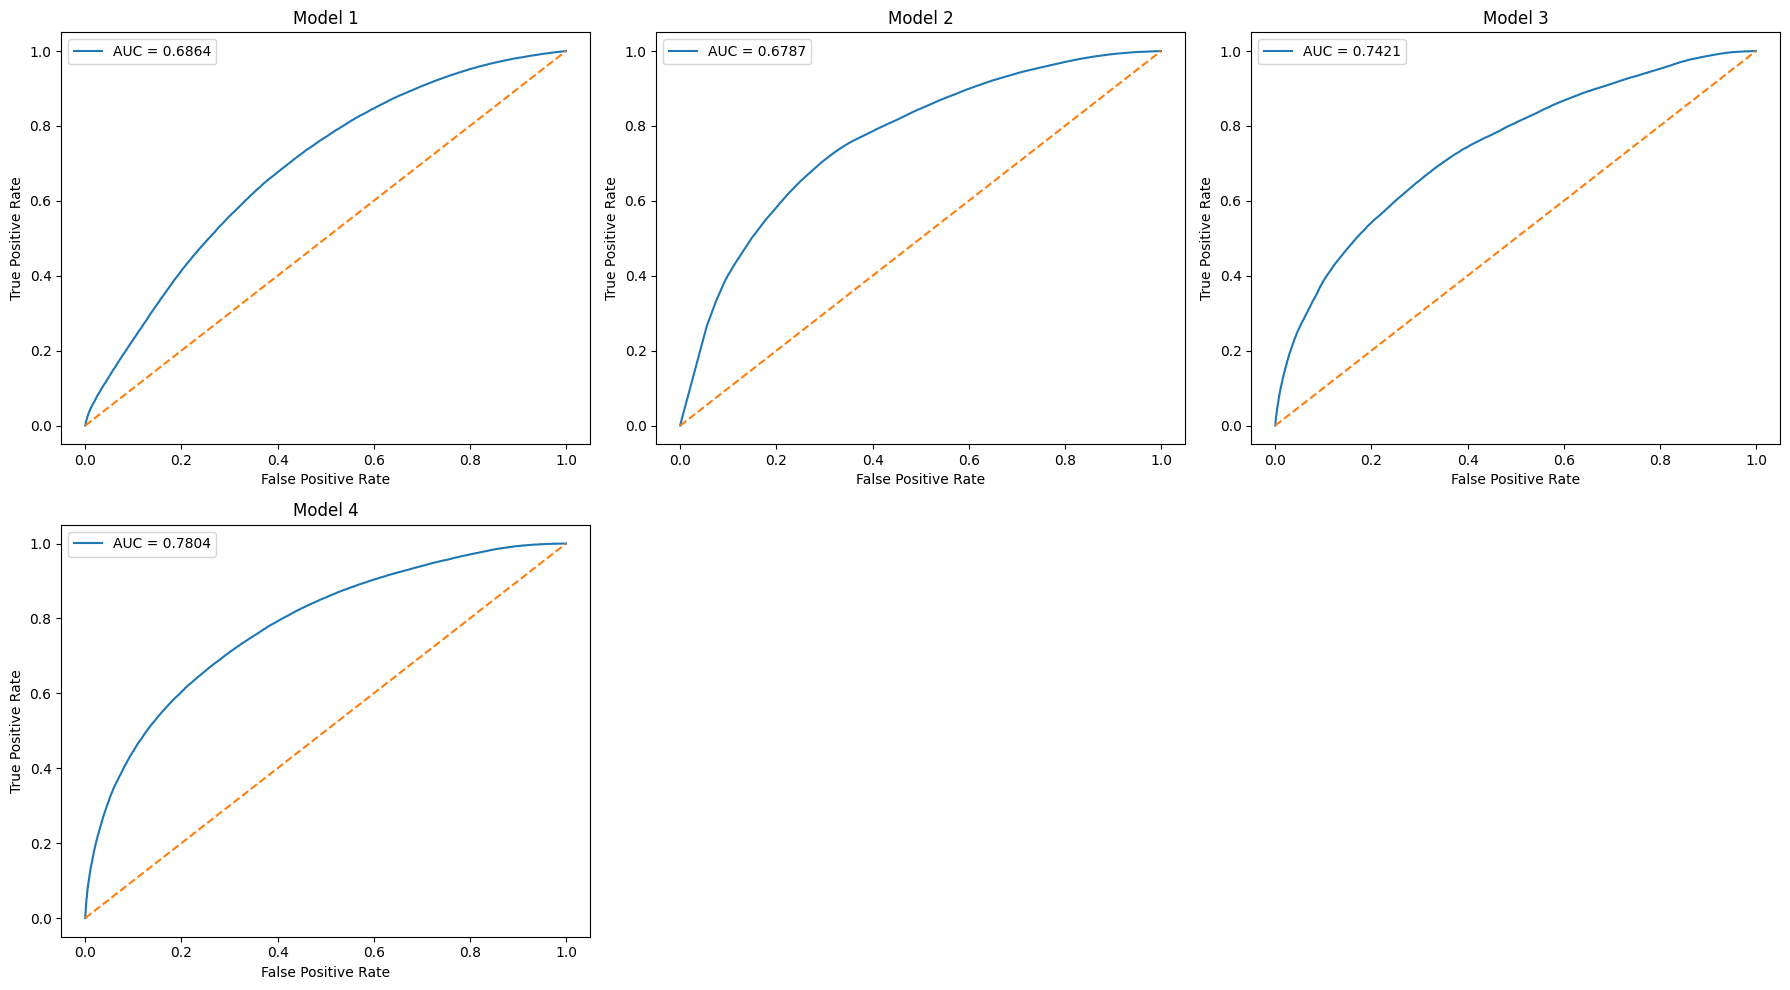

In [5]:
load_sample = spark.read.parquet("hdfs:///data/higgs_cdfrs_final_sample")
import pandas
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import math

n_models = len(model_weights_paths)
cols = 4
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = axes.flatten()

for i, path in enumerate(model_weights_paths):
    loaded_pipeline_lr = PipelineModel.load(path)
    pred = loaded_pipeline_lr.transform(load_sample)
    auc = evaluator.evaluate(pred)
    
    preds = pred.select(
        col("label"),
        vector_to_array(col("probability"))[1].alias("prob_positive")
    )
    
    pdf = preds.toPandas()
    
    fpr, tpr, thresholds = roc_curve(pdf["label"], pdf["prob_positive"])
    
    ax = axes[i]
    ax.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"Model {i+1}")
    ax.legend()

# Hide unused subplots (if any)
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


26/02/27 21:19:04 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

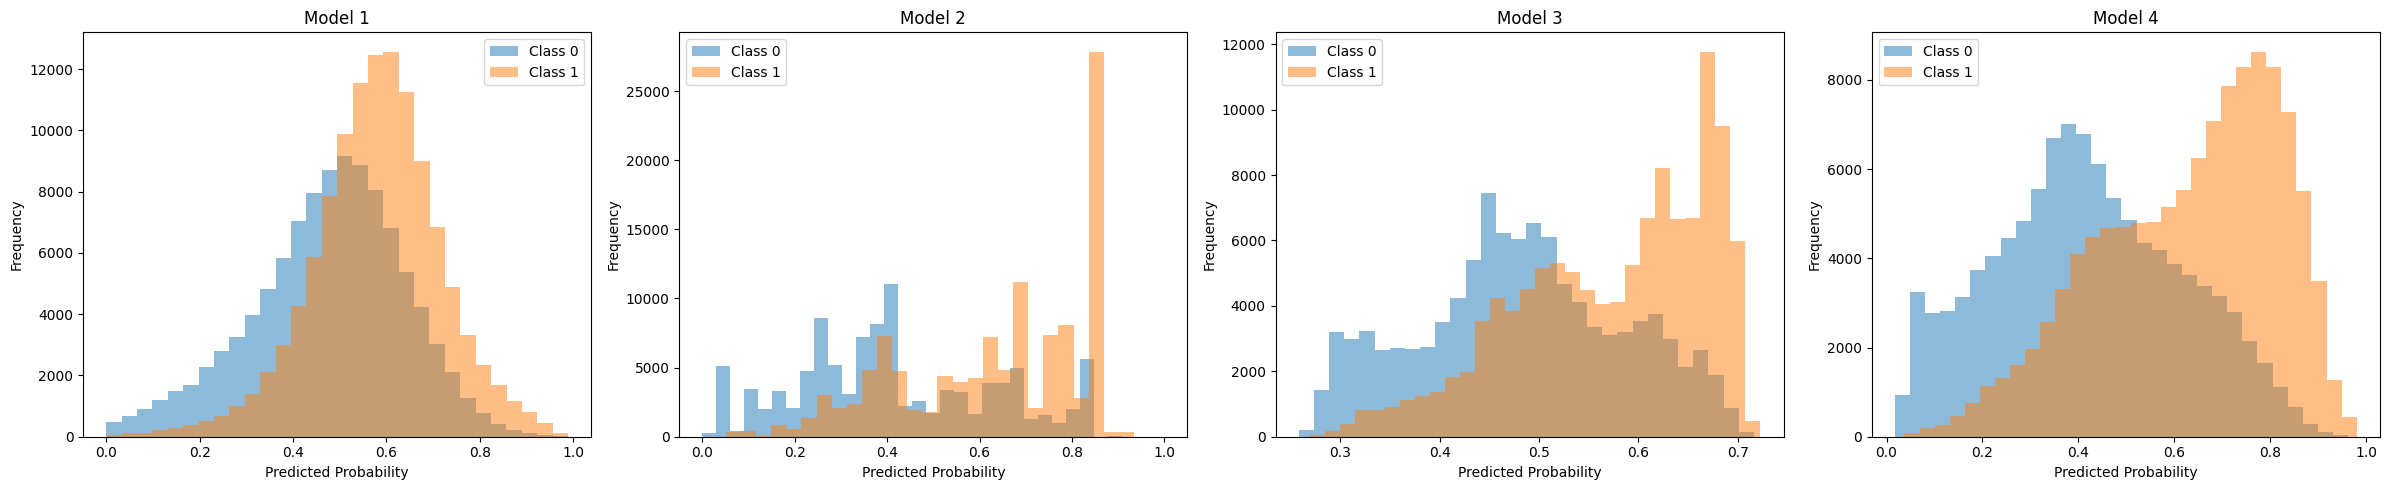

In [4]:
load_sample = spark.read.parquet("hdfs:///data/higgs_cdfrs_final_sample")
import pandas
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import math
from pyspark.ml import PipelineModel

n_models = len(model_weights_paths)
cols = 4
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = axes.flatten()

for i, path in enumerate(model_weights_paths):
    loaded_pipeline_lr = PipelineModel.load(path)
    pred = loaded_pipeline_lr.transform(load_sample)
    
    preds = pred.select(
        col("label"),
        vector_to_array(col("probability"))[1].alias("prob_positive")
    )
    
    pdf = preds.toPandas()
    
    ax = axes[i]
    
    ax.hist(
        pdf[pdf["label"] == 0]["prob_positive"],
        bins=30,
        alpha=0.5,
        label="Class 0"
    )
    
    ax.hist(
        pdf[pdf["label"] == 1]["prob_positive"],
        bins=30,
        alpha=0.5,
        label="Class 1"
    )
    
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Model {i+1}")
    ax.legend()

# Hide unused subplots
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

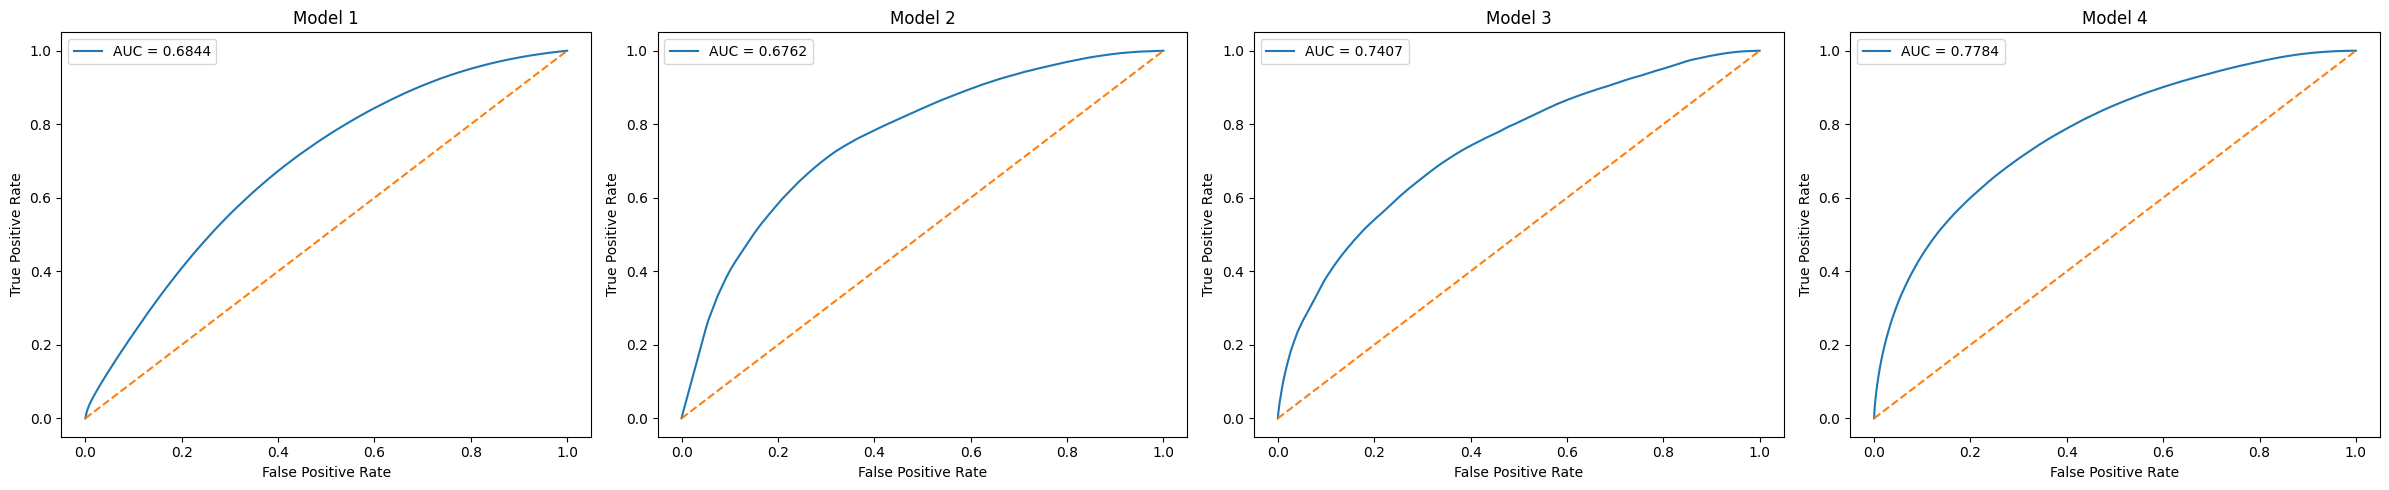

In [6]:
import pandas
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import math

n_models = len(model_weights_paths)
cols = 4
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = axes.flatten()

for i, path in enumerate(model_weights_paths):
    loaded_pipeline_lr = PipelineModel.load(path)
    pred = loaded_pipeline_lr.transform(test_full)
    auc = evaluator.evaluate(pred)
    
    preds = pred.select(
        col("label"),
        vector_to_array(col("probability"))[1].alias("prob_positive")
    )
    
    pdf = preds.toPandas()
    
    fpr, tpr, thresholds = roc_curve(pdf["label"], pdf["prob_positive"])
    
    ax = axes[i]
    ax.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"Model {i+1}")
    ax.legend()

# Hide unused subplots (if any)
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


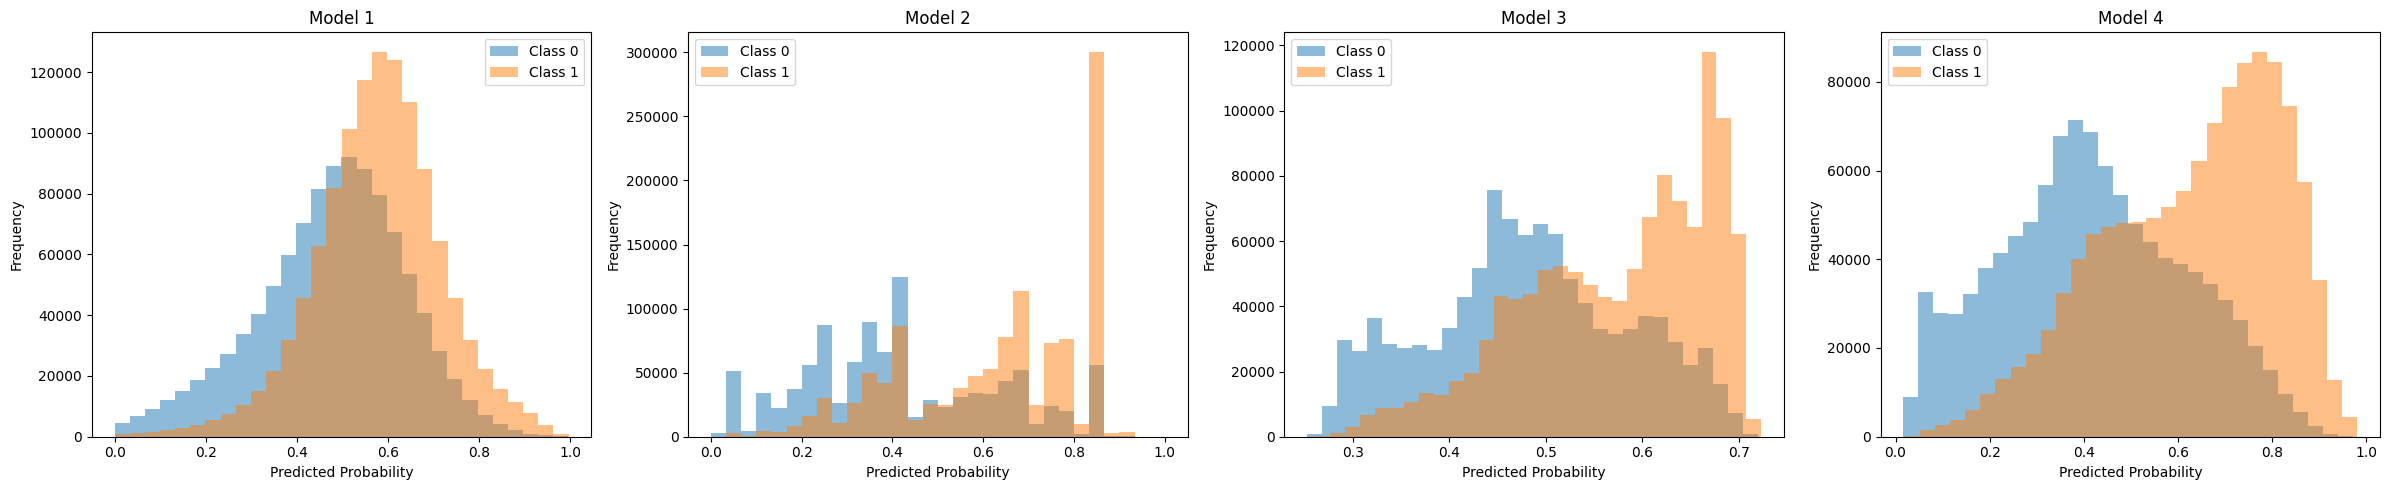

26/02/28 00:01:02 ERROR TransportClient: Failed to send RPC RPC 8375611042415079159 to /192.168.1.38:44962: io.netty.channel.StacklessClosedChannelException
io.netty.channel.StacklessClosedChannelException
	at io.netty.channel.AbstractChannel$AbstractUnsafe.write(Object, ChannelPromise)(Unknown Source)
26/02/28 00:01:02 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Attempted to get executor loss reason for executor id 2 at RPC address 192.168.1.38:44994, but got no response. Marking as agent lost.
java.io.IOException: Failed to send RPC RPC 8375611042415079159 to /192.168.1.38:44962: io.netty.channel.StacklessClosedChannelException
	at org.apache.spark.network.client.TransportClient$RpcChannelListener.handleFailure(TransportClient.java:395)
	at org.apache.spark.network.client.TransportClient$StdChannelListener.operationComplete(TransportClient.java:372)
	at io.netty.util.concurrent.DefaultPromise.notifyListener0(DefaultPromise.java:590)
	at io.netty.util.concurrent.DefaultPromise.no

In [5]:
import pandas
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import math
from pyspark.ml import PipelineModel

n_models = len(model_weights_paths)
cols = 4
rows = math.ceil(n_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = axes.flatten()

for i, path in enumerate(model_weights_paths):
    loaded_pipeline_lr = PipelineModel.load(path)
    pred = loaded_pipeline_lr.transform(test_full)
    
    preds = pred.select(
        col("label"),
        vector_to_array(col("probability"))[1].alias("prob_positive")
    )
    
    pdf = preds.toPandas()
    
    ax = axes[i]
    
    ax.hist(
        pdf[pdf["label"] == 0]["prob_positive"],
        bins=30,
        alpha=0.5,
        label="Class 0"
    )
    
    ax.hist(
        pdf[pdf["label"] == 1]["prob_positive"],
        bins=30,
        alpha=0.5,
        label="Class 1"
    )
    
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Model {i+1}")
    ax.legend()

# Hide unused subplots
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [2]:
train_cdfrs, test_cdfrs = load_sample.randomSplit([0.8,0.2], seed=42)

t0_lr = time.time()
#Logistic Regression
model_cdfrs_lr = pipeline_lr.fit(train_cdfrs)
pred_cdfrs_on_full_test_lr = model_cdfrs_lr.transform(test_full)
auc_cdfrs_lr = evaluator.evaluate(pred_cdfrs_on_full_test_lr)
t_cdfrs_lr = time.time() - t0_lr
#Decision Trees
t0_dt = time.time()
model_cdfrs_dt = pipeline_dt.fit(train_cdfrs)
pred_cdfrs_on_full_test_dt = model_cdfrs_dt.transform(test_full)
auc_cdfrs_dt = evaluator.evaluate(pred_cdfrs_on_full_test_dt)
t_cdfrs_dt= time.time() - t0_dt
#Random Forest
t0_rf = time.time()
model_cdfrs_rf = pipeline_rf.fit(train_cdfrs)
pred_cdfrs_on_full_test_rf = model_cdfrs_rf.transform(test_full)
auc_cdfrs_rf = evaluator.evaluate(pred_cdfrs_on_full_test_rf)
t_cdfrs_rf= time.time() - t0_rf
print(f" Cdfrs-Data AUC LR {auc_cdfrs_lr:.4f}, total time for LR = {t_cdfrs_lr:.1f} s")
print(f" Cdfrs-Data AUC DT {auc_cdfrs_dt:.4f}, total time for DT = {t_cdfrs_dt:.1f} s")
print(f" Cdfrs-Data AUC RF {auc_cdfrs_rf:.4f}, total time for RF = {t_cdfrs_rf:.1f} s")

NameError: name 'spark' is not defined

In [6]:
data = [("Full HIGGS", auc_full_lr, auc_full_dt, auc_full_rf, t_full_lr, t_full_dt, t_full_rf),
        ("CDFRS sample", auc_cdfrs_lr, auc_cdfrs_dt, auc_cdfrs_rf, t_cdfrs_lr, t_cdfrs_dt, t_cdfrs_rf)]
spark.createDataFrame(data, ["Training data", "AUC LR", "AUC DT", "AUC RF", "Time sec LR", "Time sec DT", "Time sec RF"]).show()

[Stage 265:>                                                        (0 + 1) / 1]

+-------------+------------------+------------------+------------------+-----------------+------------------+------------------+
|Training data|            AUC LR|            AUC DT|            AUC RF|      Time sec LR|       Time sec DT|       Time sec RF|
+-------------+------------------+------------------+------------------+-----------------+------------------+------------------+
|   Full HIGGS|0.6844405259637775|0.6712820584137513|0.7399870947007374|615.6074967384338| 779.1023619174957| 897.6520555019379|
| CDFRS sample|0.6844821819996267|0.6757038379917814|0.7427947673073294|136.7738492488861|119.58754205703735|139.34925436973572|
+-------------+------------------+------------------+------------------+-----------------+------------------+------------------+

